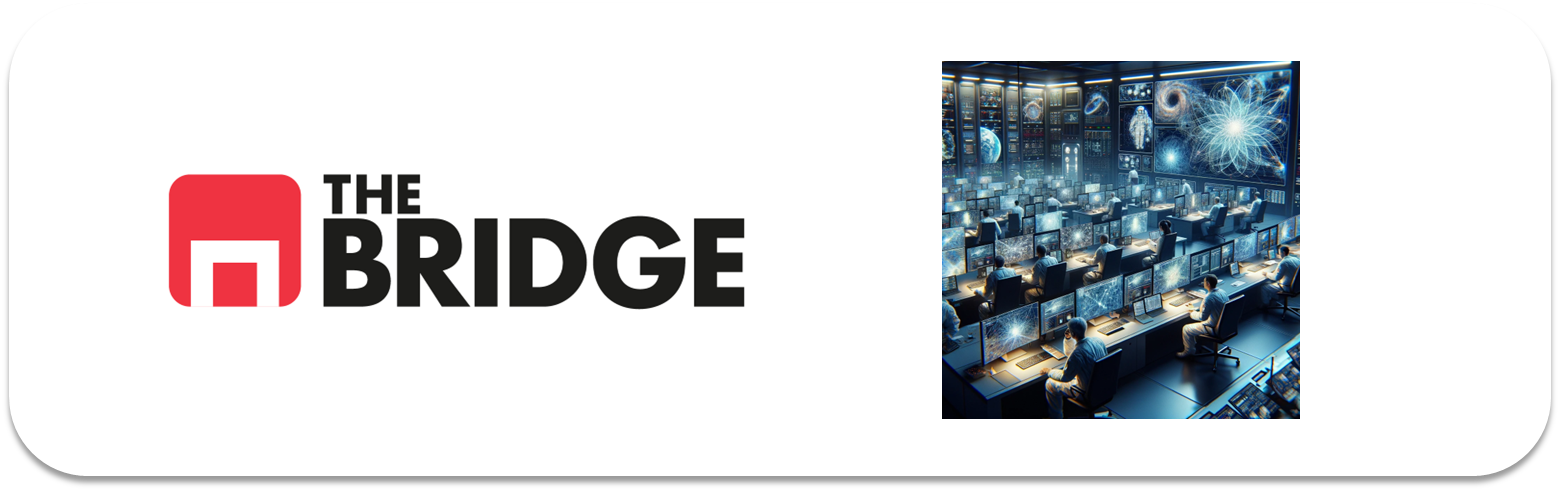

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
# --- Manejo de datos y ficheros ---
import os
import gc
import time
import numpy as np
import pandas as pd

# --- Lectura y redimensionado de imagenes ---
from skimage.io import imread
import cv2

# --- Visualizacion ---
import matplotlib.pyplot as plt
import seaborn as sns
import bootcampviztools as bt

# --- sklearn ---
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score

# --- Keras / Deep Learning ---
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import BatchNormalization

import warnings
warnings.filterwarnings("ignore")

SEMILLA = 42
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

print("TensorFlow:", tf.__version__, "| Keras:", keras.__version__)

TensorFlow: 2.21.0 | Keras: 3.15.0


### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



***
## 1. Preparación de los datos y funciones de visualización

El enunciado dice que copiemos lo que necesitemos de la solución del ejercicio de
paisajes de la unidad anterior. Reutilizamos de allí `read_data` y `plot_imagenes`,
y apuntamos a **el mismo dataset ya descargado**, sin duplicarlo.

In [2]:
# El dataset de paisajes lo tenemos ya en los ejercicios de la Unidad 1.
# Apuntamos alli en lugar de duplicar 400 MB de imagenes.
ROOT_PATH = "../../Unidad_01_CNN_Redes_Convolucionales/02_Ejercicios_Workout/data/"
TRAIN_PATH = ROOT_PATH + "seg_train/"
TEST_PATH = ROOT_PATH + "seg_test/"

for ruta, nombre in [(TRAIN_PATH, "TRAIN"), (TEST_PATH, "TEST")]:
    total = sum(len(os.listdir(os.path.join(ruta, c))) for c in sorted(os.listdir(ruta)))
    print(f"{nombre}: {total} imagenes en {len(os.listdir(ruta))} clases")

TRAIN: 14034 imagenes en 6 clases
TEST: 3000 imagenes en 6 clases


### Elección de la resolución: 75x75

Aquí hay una restricción que no teníamos en la Unidad 1. En los ejercicios anteriores
trabajamos a 32x32 y 64x64, pero **InceptionV3 no acepta imágenes por debajo de
75x75**: si le pasas un `input_shape` menor, Keras falla al construir el modelo.

Así que cargamos a **75x75**, que es el mínimo que admite. Es también la resolución
más barata para este modelo, lo cual importa porque vamos a entrenar en CPU.

In [3]:
IMG_SIZE = 75          # minimo que admite InceptionV3


def read_data(directorio, reshape_dim=(IMG_SIZE, IMG_SIZE)):
    """Lee las imagenes de un directorio etiquetandolas con el nombre de su carpeta.

    Es la misma funcion del ejercicio de paisajes de la Unidad 1.
    """
    X = []
    y = []
    for folder in sorted(os.listdir(directorio)):
        if os.path.isdir('/'.join([directorio, folder])):
            for file in os.listdir('/'.join([directorio, folder])):
                image = imread('/'.join([directorio, folder, file]))
                image = cv2.resize(image, reshape_dim)
                X.append(image)
                y.append(folder)

    return np.array(X), np.array(y)


def plot_imagenes(imagenes, etiquetas=None, n_cols=5, titulo=None):
    """Pinta un conjunto de imagenes en una rejilla, con su etiqueta encima."""
    n_filas = (len(imagenes) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols * 2, n_filas * 2.3))

    for indice, imagen in enumerate(imagenes):
        plt.subplot(n_filas, n_cols, indice + 1)
        plt.imshow(imagen)
        plt.axis("off")
        if etiquetas is not None:
            plt.title(etiquetas[indice], fontsize=9)

    if titulo:
        plt.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.show()

In [4]:
t0 = time.time()
X_train, y_train = read_data(TRAIN_PATH)
X_test, y_test = read_data(TEST_PATH)
print(f"Carga: {time.time() - t0:.0f}s")
print("X_train:", X_train.shape, X_train.dtype)
print("X_test :", X_test.shape)
print(f"Memoria: {(X_train.nbytes + X_test.nbytes) / 1e6:.0f} MB")

Carga: 60s
X_train: (14034, 75, 75, 3) uint8
X_test : (3000, 75, 75, 3)
Memoria: 287 MB


### Visualización y MiniEDA

A 75x75 las imágenes se ven bastante mejor que a los 32x32 de la unidad anterior:
ya se aprecian texturas y detalles. Eso ya es una ventaja de por sí, independiente
del modelo preentrenado.

Clases: [np.str_('buildings'), np.str_('forest'), np.str_('glacier'), np.str_('mountain'), np.str_('sea'), np.str_('street')]


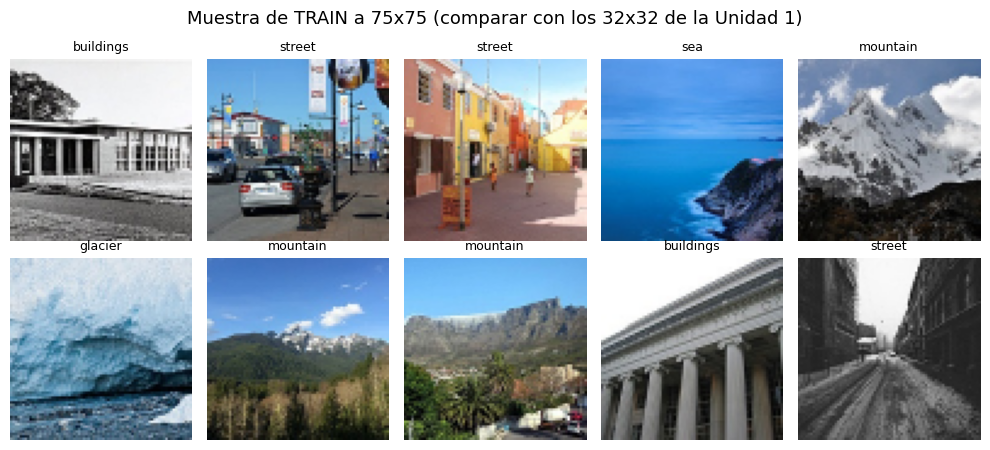

In [5]:
CLASES = sorted(np.unique(y_train))
print("Clases:", list(CLASES))

indices = np.random.choice(len(X_train), 10, replace=False)
plot_imagenes(X_train[indices], y_train[indices], n_cols=5,
              titulo="Muestra de TRAIN a 75x75 (comparar con los 32x32 de la Unidad 1)")

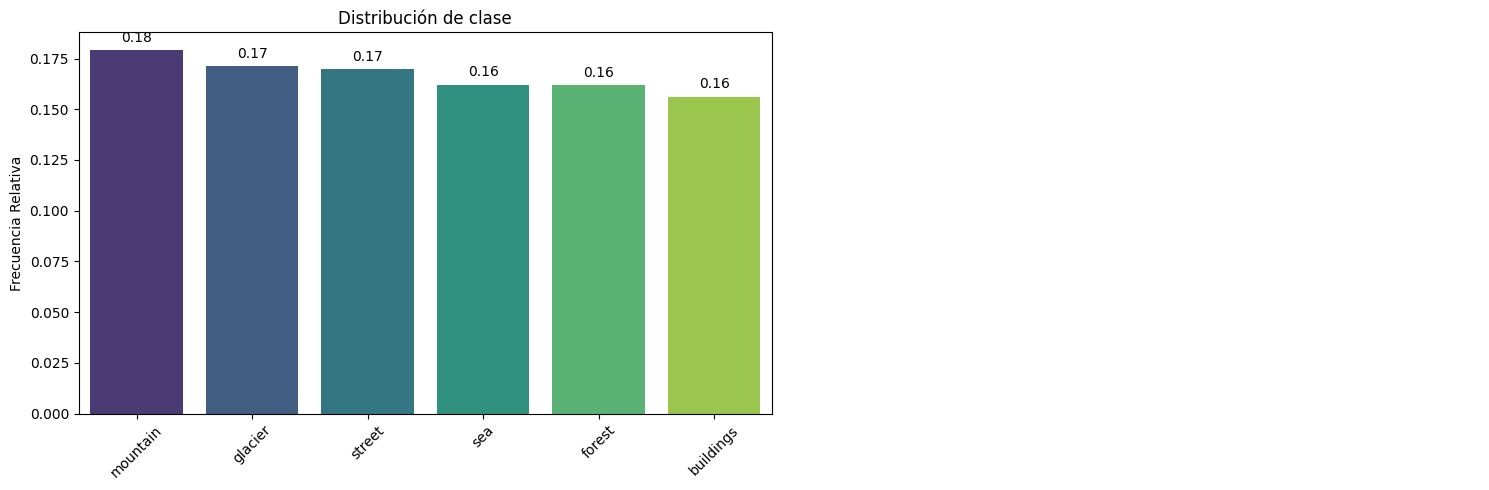

In [6]:
# MiniEDA: distribucion del target, con las utilidades del bootcamp
df_train = pd.DataFrame({"clase": y_train})
bt.pinta_distribucion_categoricas(df_train, ["clase"], relativa=True, mostrar_valores=True)

Las 6 clases siguen equilibradas (entre el 15,6% y el 17,9%), así que **`accuracy`**
nos vale como métrica, igual que en la Unidad 1.

Las referencias contra las que compararemos al final:

| referencia | accuracy |
|---|---|
| azar (6 clases) | 16,7% |
| baseline RandomForest (Unidad 1) | 60,4% |
| **CNN desde cero a 32x32 (Unidad 1)** | **79,6%** |
| **CNN desde cero a 64x64 (Unidad 1)** | **82,4%** |

El objetivo de esta práctica es ver si un modelo preentrenado bate esos dos últimos
números, que ya son buenos.

### Transformación de features: aquí hay un cambio importante

En la Unidad 1 escalábamos dividiendo por 255, para dejar los píxeles en [0, 1].
**Con un modelo preentrenado eso no vale.** Cada arquitectura se entrenó con un
preprocesado concreto, y hay que reproducirlo exactamente o las features que hemos
heredado no significan lo que deberían.

InceptionV3 espera los valores en **[-1, 1]**, no en [0, 1]. Keras nos da la función
correcta para cada familia de modelos, así que la usamos en lugar de improvisar:

In [7]:
# preprocess_input de inception_v3 mapea [0, 255] -> [-1, 1]
# Lo comprobamos con los valores extremos antes de aplicarlo a todo:
for v in (0.0, 127.5, 255.0):
    prueba = np.array([[[[v, v, v]]]], dtype="float32")
    print(f"  pixel {v:6} -> {preprocess_input(prueba)[0, 0, 0, 0]:+.2f}")

  pixel    0.0 -> -1.00
  pixel  127.5 -> +0.00
  pixel  255.0 -> +1.00


In [8]:
# Guardamos una muestra pequena SIN preprocesar, para poder pintar imagenes despues
# (una vez en [-1,1] ya no se ven bien con imshow)
np.random.seed(SEMILLA)
idx_muestra = np.random.choice(len(X_test), 40, replace=False)
X_test_visual = X_test[idx_muestra].copy()

# Convertimos a float32 y preprocesamos. preprocess_input trabaja in-place sobre
# float32, asi que no duplicamos la memoria.
X_train_pre = preprocess_input(X_train.astype("float32"))
X_test_pre = preprocess_input(X_test.astype("float32"))

print("Rango tras preprocesar:", X_train_pre.min(), "a", X_train_pre.max())
print(f"Memoria: {(X_train_pre.nbytes + X_test_pre.nbytes) / 1e6:.0f} MB")

# Liberamos los uint8 originales, que ya no necesitamos
del X_train, X_test
gc.collect()

Rango tras preprocesar: -1.0 a 1.0
Memoria: 1150 MB


19237

In [9]:
# Etiquetas a numero, con los dos diccionarios de traduccion
clase_a_numero = {c: i for i, c in enumerate(CLASES)}
numero_a_clase = {i: c for c, i in clase_a_numero.items()}

y_train_num = np.array([clase_a_numero[c] for c in y_train])
y_test_num = np.array([clase_a_numero[c] for c in y_test])

# Barajado: los datos vienen agrupados por clase (misma trampa que en la Unidad 1),
# y vamos a usar validation_split, que coge el ultimo 20% sin barajar.
X_train_pre, y_train_num = shuffle(X_train_pre, y_train_num, random_state=SEMILLA)

corte = int(len(y_train_num) * 0.8)
clases_val, cuentas_val = np.unique(y_train_num[corte:], return_counts=True)
print("Clases en el 20% de validacion tras barajar:")
for c, n in zip(clases_val, cuentas_val):
    print(f"   {numero_a_clase[c]:12} {n}")

Clases en el 20% de validacion tras barajar:
   buildings    430
   forest       436
   glacier      474
   mountain     514
   sea          477
   street       476


***
## 2. Selección del modelo a transferir

El enunciado da a elegir entre **VGG-19, InceptionV3 y MobileNetV2** (o ResNet50V2 si
los otros no salen), y aconseja MobileNetV2 si el ordenador no es potente.

Antes de decidir, medimos los candidatos. Los parámetros y el input mínimo son
propiedades del modelo, así que se pueden consultar sin entrenar nada:

In [10]:
from tensorflow.keras.applications import VGG19, MobileNetV2, ResNet50V2

candidatos = [("VGG19", VGG19), ("InceptionV3", InceptionV3),
              ("MobileNetV2", MobileNetV2), ("ResNet50V2", ResNet50V2)]

filas = []
for nombre, constructor in candidatos:
    # buscamos el input minimo que acepta cada uno
    minimo = None
    for s in (32, 71, 75, 96):
        try:
            constructor(include_top=False, weights=None, input_shape=(s, s, 3))
            minimo = s
            break
        except Exception:
            pass

    m = constructor(include_top=False, weights=None, input_shape=(96, 96, 3))
    filas.append({
        "modelo": nombre,
        "params_sin_cabeza": m.count_params(),
        "capas": len(m.layers),
        "capas_BatchNorm": sum(1 for l in m.layers if isinstance(l, BatchNormalization)),
        "input_minimo": f"{minimo}x{minimo}",
    })
    del m
    gc.collect()

pd.DataFrame(filas)

,modelo,params_sin_cabeza,capas,capas_BatchNorm,input_minimo
0,VGG19,20024384,22,0,32x32
1,InceptionV3,21802784,311,94,75x75
2,MobileNetV2,2257984,154,52,32x32
3,ResNet50V2,23564800,190,49,32x32


**Decisión: InceptionV3 a 75x75.**

Por qué:

* Es un buen punto medio: **21,8 millones de parámetros**, cuatro veces menos que
  VGG19 (que se va a los 20 millones solo en la base y encima es la más lenta por
  capa), y sin ser tan minúsculo como MobileNetV2.
* Su input mínimo de **75x75** encaja con nuestro presupuesto de cómputo. Es la
  restricción que nos ha fijado la resolución.
* Es el modelo que usa la solución de referencia del curso, así que podremos
  comparar directamente nuestros resultados con los suyos.

Y el aviso: **tiene 94 capas BatchNormalization**. Eso no molesta para el transfer
learning, pero es determinante en el fine-tuning y volveremos sobre ello en el punto
4.

Sobre el coste, medido antes de empezar en esta máquina (solo CPU, sin GPU):

| fase | segundos por época (14.034 imágenes) |
|---|---|
| transfer learning (base congelada) | ~25 s |
| fine-tuning (base entrenable) | ~165 s |

Los 165 segundos vienen de que en el fine-tuning hay que calcular gradientes para
los 22 millones de parámetros de la base, no solo para la cabeza. Es la razón por la
que la teoría dice que el fine-tuning es "más lento que el transfer learning puro".

***
## 4. Transfer Learning

El procedimiento de la teoría, en sus cuatro pasos:

1. **Selección del modelo**: InceptionV3 (hecho en el punto 2).
2. **Descarga**: con `weights='imagenet'` para traernos los pesos entrenados.
3. **Sustitución de la cabeza**: `include_top=False` para quitar su clasificador de
   1000 clases, y encima ponemos el nuestro de 6.
4. **Entrenamiento sin tocar la base**: congelamos todas sus capas.

La cabeza, respetando el límite del enunciado ("como mucho 2 capas densas ocultas y
una de salida"), usa **una sola oculta**:

`Flatten` (2048 features) → `Dense(256, relu)` → `Dropout(0.5)` → `Dense(6, softmax)`

Con una capa oculta ya son 524.544 parámetros entrenables. Añadir una segunda
aumentaría el riesgo de overfitting sin necesidad: la base preentrenada ya hace el
trabajo duro de extraer features.

In [11]:
def construye_modelo(congelar_base=True, semilla=SEMILLA):
    """Monta InceptionV3 preentrenada + nuestra cabeza de clasificacion.

    Args:
        congelar_base: si True, la base no se entrena (transfer learning puro).
        semilla: para que la inicializacion de la cabeza sea reproducible.

    Returns:
        El modelo de Keras sin compilar.
    """
    tf.random.set_seed(semilla)

    base = InceptionV3(include_top=False,
                       weights="imagenet",          # IMPORTANTE: con los pesos
                       input_shape=(IMG_SIZE, IMG_SIZE, 3))

    base.trainable = not congelar_base

    # --- Nuestra cabeza (API funcional, porque enganchamos sobre un modelo ya hecho) ---
    x = layers.Flatten()(base.output)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    salida = layers.Dense(len(CLASES), activation="softmax")(x)

    return keras.Model(base.input, salida)


model_tl = construye_modelo(congelar_base=True)

model_tl.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])

total = model_tl.count_params()
entrenables = sum(int(tf.size(w)) for w in model_tl.trainable_weights)
PARAMS_TL = entrenables   # lo guardamos: mas adelante descongelamos este mismo modelo
print(f"Parametros totales    : {total:,}")
print(f"Parametros entrenables: {entrenables:,}  ({entrenables/total:.1%})")
print(f"Parametros heredados  : {total - entrenables:,}  ({1 - entrenables/total:.1%})")

Parametros totales    : 22,328,870
Parametros entrenables: 526,086  (2.4%)
Parametros heredados  : 21,802,784  (97.6%)


Ahí está la idea central de la unidad en dos números: entrenamos el **2,4%** del
modelo y heredamos el 97,6%. Con 14.000 imágenes eso es lo que hace la diferencia
entre poder y no poder.

El learning rate lo dejamos en el 0.001 por defecto de Adam: como la base está
congelada, solo estamos entrenando una cabeza nueva desde cero y no hay riesgo de
estropear nada heredado.

In [12]:
early = EarlyStopping(monitor="val_loss", patience=5,
                      restore_best_weights=True, verbose=1)

t0 = time.time()
hist_tl = model_tl.fit(X_train_pre, y_train_num,
                       batch_size=64,
                       epochs=30,
                       validation_split=0.2,
                       callbacks=[early],
                       verbose=2)
print(f"\nEntrenamiento: {time.time() - t0:.0f}s")

Epoch 1/30


176/176 - 33s - 185ms/step - accuracy: 0.6815 - loss: 0.8670 - val_accuracy: 0.7681 - val_loss: 0.6389


Epoch 2/30


176/176 - 23s - 132ms/step - accuracy: 0.7830 - loss: 0.5859 - val_accuracy: 0.7805 - val_loss: 0.5909


Epoch 3/30


...

Epoch 9/30


176/176 - 23s - 131ms/step - accuracy: 0.9151 - loss: 0.2375 - val_accuracy: 0.7884 - val_loss: 0.6674


Epoch 9: early stopping


Restoring model weights from the end of the best epoch: 4.



Entrenamiento: 220s


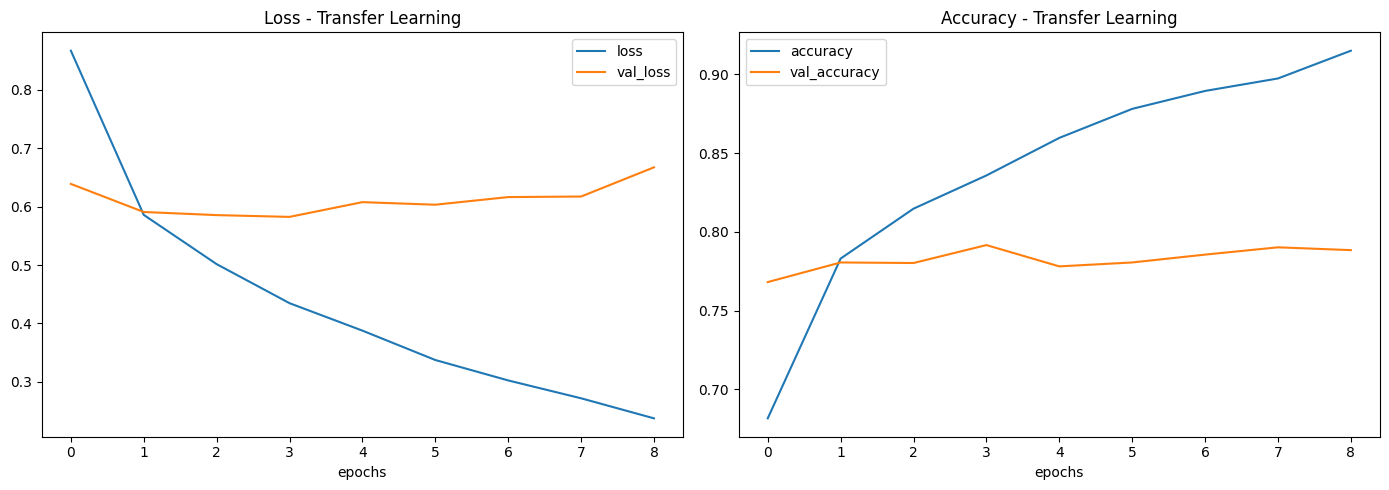

Epocas: 9 | mejor val_loss 0.5825 en epoca 4
En esa epoca: accuracy=0.8358 val_accuracy=0.7916 (diferencia +0.0442)


In [13]:
def pinta_historial(historial, titulo):
    """Pinta loss y accuracy de train y validacion."""
    df = pd.DataFrame(historial.history)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    df[["loss", "val_loss"]].plot(ax=axes[0])
    axes[0].set_title(f"Loss - {titulo}")
    axes[0].set_xlabel("epochs")

    df[["accuracy", "val_accuracy"]].plot(ax=axes[1])
    axes[1].set_title(f"Accuracy - {titulo}")
    axes[1].set_xlabel("epochs")

    plt.tight_layout()
    plt.show()

    mejor = df["val_loss"].idxmin()
    print(f"Epocas: {len(df)} | mejor val_loss {df['val_loss'].min():.4f} "
          f"en epoca {mejor + 1}")
    print(f"En esa epoca: accuracy={df.loc[mejor, 'accuracy']:.4f} "
          f"val_accuracy={df.loc[mejor, 'val_accuracy']:.4f} "
          f"(diferencia {df.loc[mejor, 'accuracy'] - df.loc[mejor, 'val_accuracy']:+.4f})")
    return df


hist_tl_df = pinta_historial(hist_tl, "Transfer Learning")

In [14]:
def evalua(modelo, nombre, X, y):
    """Evalua contra test y devuelve las metricas y predicciones."""
    loss, acc = modelo.evaluate(X, y, verbose=0)
    print(f"=== {nombre} ===")
    print(f"Loss en test    : {loss:.4f}")
    print(f"Accuracy en test: {acc:.4f}  ({acc:.1%})")
    print()

    probs = modelo.predict(X, verbose=0)
    pred = np.argmax(probs, axis=1)
    conf = np.max(probs, axis=1)

    print(classification_report(y, pred, target_names=CLASES))
    return {"loss": loss, "accuracy": acc, "pred": pred, "conf": conf}


res_tl = evalua(model_tl, "TRANSFER LEARNING", X_test_pre, y_test_num)

=== TRANSFER LEARNING ===
Loss en test    : 0.5695
Accuracy en test: 0.7917  (79.2%)



              precision    recall  f1-score   support

   buildings       0.78      0.83      0.81       437
      forest       0.90      0.96      0.93       474
     glacier       0.77      0.67      0.71       553
    mountain       0.69      0.74      0.71       525
         sea       0.80      0.75      0.78       510
      street       0.82      0.82      0.82       501

    accuracy                           0.79      3000
   macro avg       0.79      0.80      0.79      3000
weighted avg       0.79      0.79      0.79      3000



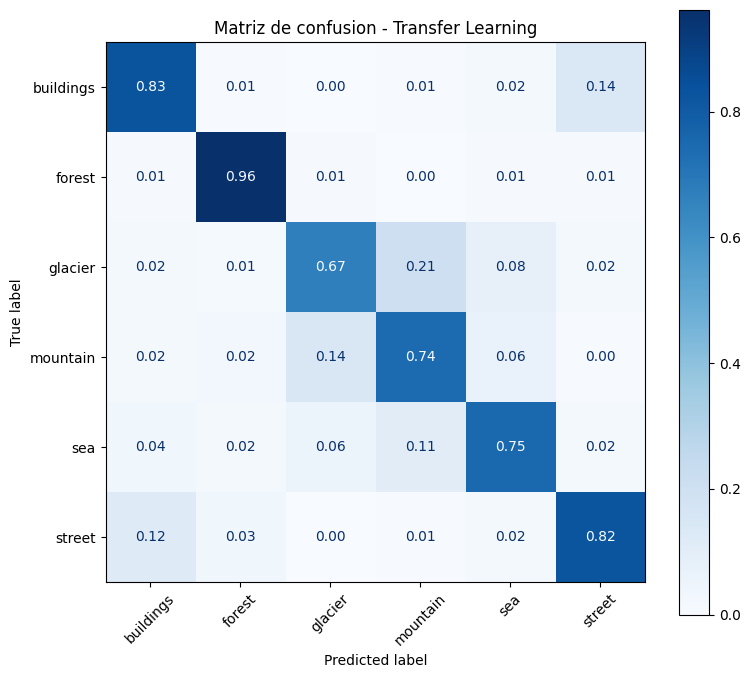

In [15]:
def pinta_matriz(y_real, y_pred, titulo, cmap="Blues"):
    fig, ax = plt.subplots(figsize=(8, 7))
    ConfusionMatrixDisplay.from_predictions(
        y_real, y_pred, display_labels=CLASES, cmap=cmap,
        normalize="true", values_format=".2f", xticks_rotation=45, ax=ax)
    ax.set_title(titulo)
    plt.tight_layout()
    plt.show()


pinta_matriz(y_test_num, res_tl["pred"], "Matriz de confusion - Transfer Learning")

**Lectura del transfer learning**

Accuracy en test: **79,2%**. El entrenamiento fue muy corto (9 épocas, con la mejor
en la 4), lo cual es esperable: solo estábamos ajustando una cabeza de 526.086
parámetros sobre features ya buenas.

Por clases se repite el patrón que ya conocemos del ejercicio de la Unidad 1:

| clase | f1 |
|---|---|
| forest | **0.93** |
| street | 0.82 |
| buildings | 0.81 |
| sea | 0.78 |
| mountain | **0.72** |
| glacier | **0.71** |

`forest` sigue siendo la fácil y el par `glacier`/`mountain` sigue siendo el problema.
El recall de `glacier` es de solo 0.67: se le escapa un tercio de los glaciares.

**Y aquí hay un resultado que no esperaba.** Comparado con la CNN que entrenamos desde
cero en la Unidad 1, el transfer learning **no gana**:

| modelo | accuracy |
|---|---|
| CNN desde cero, 32x32 (U1) | 79,6% |
| CNN desde cero, 64x64 (U1) | **82,4%** |
| InceptionV3 transfer, 75x75 | 79,2% |

Empata con la versión de 32x32 y queda 3 puntos por debajo de la de 64x64, ¡y eso
usando un extractor de features entrenado con más de un millón de imágenes! Volvemos
sobre esto en el punto 6, porque tiene explicación.

***
## 5. Fine-Tuning

Ahora descongelamos la base para que se ajuste a nuestro problema. Hay **tres
decisiones** en este paso que son las que separan un fine-tuning que funciona de uno
que destroza el modelo.

### 5.1 El orden importa: partimos del modelo ya entrenado

No construimos un modelo nuevo. Partimos del **modelo de transfer learning que
acabamos de entrenar** y le descongelamos la base.

El motivo: si descongelas la base con una cabeza recién inicializada al azar, esa
cabeza produce errores enormes en las primeras iteraciones, y esos gradientes enormes
se propagan hacia atrás y **arrasan los pesos preentrenados** antes de que la red
tenga tiempo de aprender nada. Es el fenómeno de *catastrophic forgetting*, y se
reconoce porque la `val_loss` de la primera época se dispara a valores absurdos
(miles, en lugar de estar cerca de 1).

Entrenando primero la cabeza (lo que ya hicimos) y descongelando después, los
gradientes que llegan a la base son pequeños desde el principio.

### 5.2 Learning rate bajo

Con la base descongelada usamos **`learning_rate=1e-5`**, cien veces menor que el
0.001 del transfer. Estamos *afinando* pesos que ya son buenos, no aprendiendo desde
cero: pasos grandes solo pueden empeorarlos.

### 5.3 Las 94 capas BatchNormalization se quedan congeladas

Esta es la parte menos evidente. Las capas `BatchNormalization` guardan medias y
varianzas calculadas sobre ImageNet (más de un millón de imágenes). Si las
descongelamos, empiezan a recalcular esas estadísticas con **nuestros batches de 64
imágenes**, que son una muestra pequeña y sesgada, y las estropean.

La recomendación de la documentación de Keras es mantenerlas en modo inferencia. Lo
hacemos poniendo `trainable = False` solo en ellas.

In [16]:
# Partimos del modelo de transfer learning ya entrenado
model_ft = model_tl

# Descongelamos toda la base...
for capa in model_ft.layers:
    capa.trainable = True

# ...excepto las BatchNormalization, que se quedan en modo inferencia
n_bn = 0
for capa in model_ft.layers:
    if isinstance(capa, BatchNormalization):
        capa.trainable = False
        n_bn += 1

print(f"Capas BatchNormalization congeladas: {n_bn}")

# IMPRESCINDIBLE: recompilar para que los cambios de 'trainable' surtan efecto,
# y aqui es donde bajamos el learning rate
model_ft.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),
                 loss="sparse_categorical_crossentropy",
                 metrics=["accuracy"])

total = model_ft.count_params()
entrenables = sum(int(tf.size(w)) for w in model_ft.trainable_weights)
PARAMS_FT = entrenables
print(f"Parametros entrenables ahora: {entrenables:,} de {total:,} "
      f"({entrenables/total:.1%})")

Capas BatchNormalization congeladas: 94
Parametros entrenables ahora: 22,277,222 de 22,328,870 (99.8%)


Hemos pasado de entrenar el 2,4% del modelo a entrenar más del 90%. De ahí que cada
época pase de ~25 a ~165 segundos.

Bajamos `epochs` y la `patience` respecto al transfer, precisamente por ese coste: a
165 segundos por época, una paciencia de 5 son 14 minutos solo para confirmar que ya
no mejora.

In [17]:
early_ft = EarlyStopping(monitor="val_loss", patience=3,
                         restore_best_weights=True, verbose=1)

t0 = time.time()
hist_ft = model_ft.fit(X_train_pre, y_train_num,
                       batch_size=64,
                       epochs=12,
                       validation_split=0.2,
                       callbacks=[early_ft],
                       verbose=2)
print(f"\nEntrenamiento: {time.time() - t0:.0f}s")

Epoch 1/12


176/176 - 124s - 703ms/step - accuracy: 0.8684 - loss: 0.3551 - val_accuracy: 0.8372 - val_loss: 0.4555


Epoch 2/12


176/176 - 107s - 605ms/step - accuracy: 0.9218 - loss: 0.2109 - val_accuracy: 0.8486 - val_loss: 0.4609


Epoch 3/12


...

Epoch 4/12


176/176 - 109s - 618ms/step - accuracy: 0.9664 - loss: 0.0957 - val_accuracy: 0.8507 - val_loss: 0.5399


Epoch 4: early stopping


Restoring model weights from the end of the best epoch: 1.



Entrenamiento: 461s


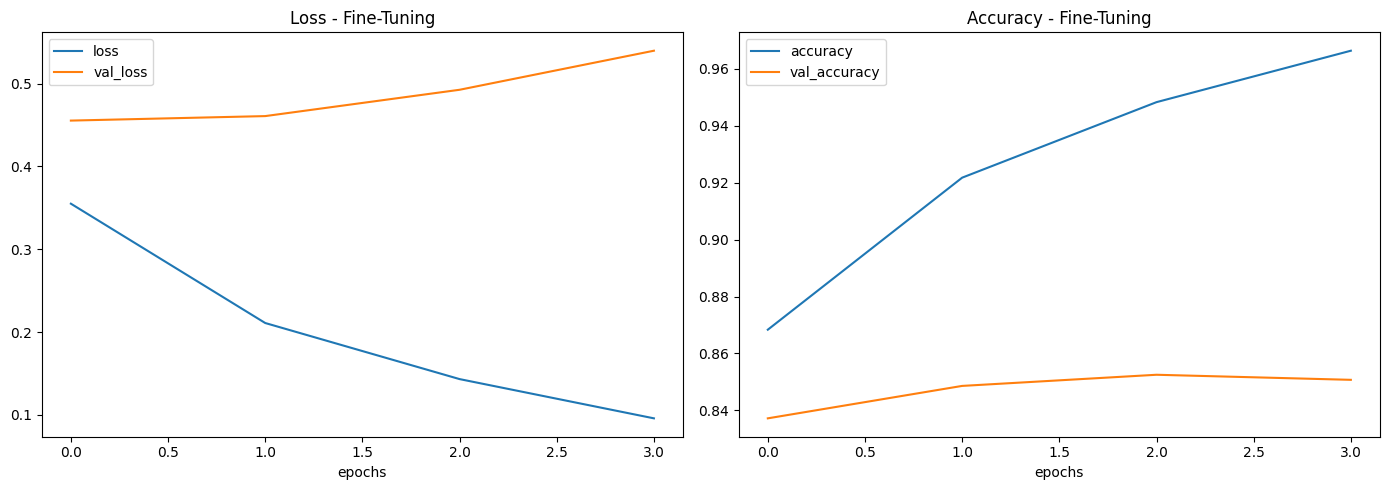

Epocas: 4 | mejor val_loss 0.4555 en epoca 1
En esa epoca: accuracy=0.8684 val_accuracy=0.8372 (diferencia +0.0312)


In [18]:
hist_ft_df = pinta_historial(hist_ft, "Fine-Tuning")

In [19]:
res_ft = evalua(model_ft, "FINE-TUNING", X_test_pre, y_test_num)

=== FINE-TUNING ===
Loss en test    : 0.4516
Accuracy en test: 0.8400  (84.0%)



              precision    recall  f1-score   support

   buildings       0.85      0.83      0.84       437
      forest       0.96      0.96      0.96       474
     glacier       0.83      0.72      0.77       553
    mountain       0.73      0.80      0.76       525
         sea       0.85      0.85      0.85       510
      street       0.84      0.90      0.87       501

    accuracy                           0.84      3000
   macro avg       0.84      0.84      0.84      3000
weighted avg       0.84      0.84      0.84      3000



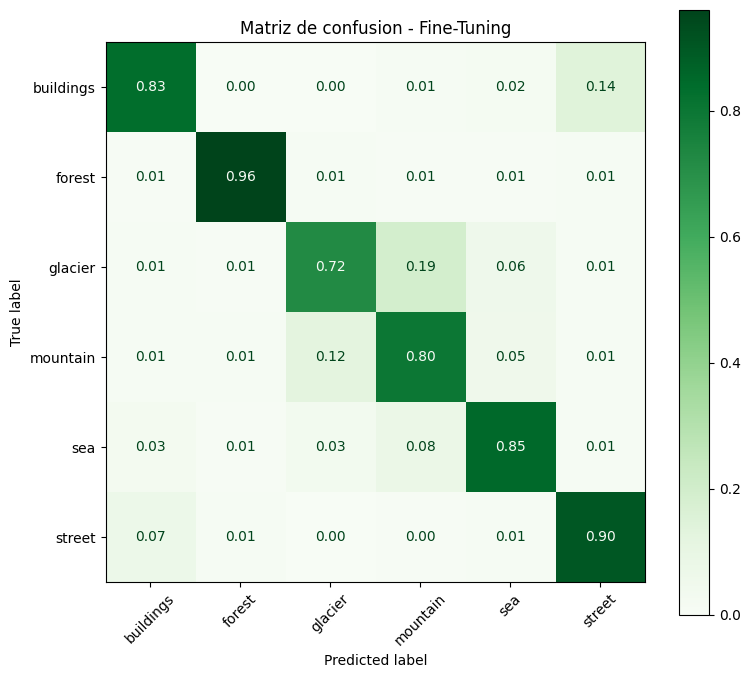

In [20]:
pinta_matriz(y_test_num, res_ft["pred"], "Matriz de confusion - Fine-Tuning", cmap="Greens")

**Lectura del fine-tuning**

Accuracy en test: **84,0%**, frente al 79,2% del transfer. **Casi 5 puntos de mejora**
solo por dejar que la base se ajuste a nuestros paisajes.

Y las precauciones del punto 5 se ven en los números:

* La `val_loss` de la primera época es **0.4555**, que ya es *mejor* que el 0.5825
  al que había llegado el transfer. No hay ninguna explosión. Si hubiéramos
  descongelado con una cabeza aleatoria y un learning rate alto, aquí veríamos
  valores de miles.
* De hecho **la primera época ya fue la mejor**, y el EarlyStopping paró en la cuarta.
  Partiendo de una cabeza entrenada y con `learning_rate=1e-5`, al modelo le bastó
  una pasada para colocarse.

El precio es que **sobreajusta muy rápido**: en la época 4 la accuracy de train ya iba
por el 96,6% frente al 85,1% de validación. Con 22 millones de parámetros entrenables
y 14.000 imágenes, eso era inevitable. El `restore_best_weights=True` es lo que nos
salva de llevarnos ese modelo degradado.

Por clases, todas mejoran respecto al transfer:

| clase | f1 transfer | f1 fine-tuning |
|---|---|---|
| forest | 0.93 | **0.96** |
| street | 0.82 | **0.87** |
| sea | 0.78 | **0.85** |
| buildings | 0.81 | **0.84** |
| glacier | 0.71 | 0.77 |
| mountain | 0.72 | 0.76 |

Fíjate en la primera época del entrenamiento: la `val_loss` arranca **cerca del valor
donde había terminado el transfer learning**, no en miles. Eso confirma que las tres
precauciones del punto 5 han funcionado: la base preentrenada ha sobrevivido al
descongelado.

***
## 6. Comparación con la red convolucional de la unidad anterior

Los números de la CNN construida desde cero salen del ejercicio de paisajes de la
Unidad 1 (`13_Ejercicios_Practica_Redes_Convolucionales.ipynb`), donde entrenamos la
misma topología a dos resoluciones.

In [21]:
# Resultados de la CNN desde cero, del ejercicio de la Unidad 1
comparativa = pd.DataFrame([
    {"modelo": "RandomForest (baseline U1)", "resolucion": "32x32",
     "params_entrenados": 0, "accuracy_test": 0.6037},
    {"modelo": "CNN desde cero (U1)", "resolucion": "32x32",
     "params_entrenados": 619334, "accuracy_test": 0.7960},
    {"modelo": "CNN desde cero (U1)", "resolucion": "64x64",
     "params_entrenados": 2192198, "accuracy_test": 0.8243},
    {"modelo": "InceptionV3 Transfer Learning", "resolucion": "75x75",
     "params_entrenados": PARAMS_TL,
     "accuracy_test": res_tl["accuracy"]},
    {"modelo": "InceptionV3 Fine-Tuning", "resolucion": "75x75",
     "params_entrenados": PARAMS_FT,
     "accuracy_test": res_ft["accuracy"]},
])
comparativa["accuracy_test"] = comparativa["accuracy_test"].round(4)
comparativa

,modelo,resolucion,params_entrenados,accuracy_test
0,RandomForest (baseline U1),32x32,0,0.6037
1,CNN desde cero (U1),32x32,619334,0.7960
2,CNN desde cero (U1),64x64,2192198,0.8243
3,InceptionV3 Transfer Learning,75x75,526086,0.7917
4,InceptionV3 Fine-Tuning,75x75,22277222,0.8400


In [22]:
# f1 por clase de los tres modelos comparables
f1_cnn_32 = [0.742, 0.908, 0.775, 0.769, 0.768, 0.820]     # de la Unidad 1
f1_cnn_64 = [0.794, 0.938, 0.784, 0.783, 0.810, 0.842]     # de la Unidad 1

df_f1 = pd.DataFrame({
    "clase": CLASES,
    "CNN_32x32": f1_cnn_32,
    "CNN_64x64": f1_cnn_64,
    "Transfer": np.round(f1_score(y_test_num, res_tl["pred"], average=None), 3),
    "FineTuning": np.round(f1_score(y_test_num, res_ft["pred"], average=None), 3),
})
df_f1

,clase,CNN_32x32,CNN_64x64,Transfer,FineTuning
0,buildings,0.742,0.794,0.805,0.843
1,forest,0.908,0.938,0.929,0.959
2,glacier,0.775,0.784,0.714,0.770
3,mountain,0.769,0.783,0.715,0.763
4,sea,0.768,0.810,0.777,0.849
5,street,0.820,0.842,0.824,0.871


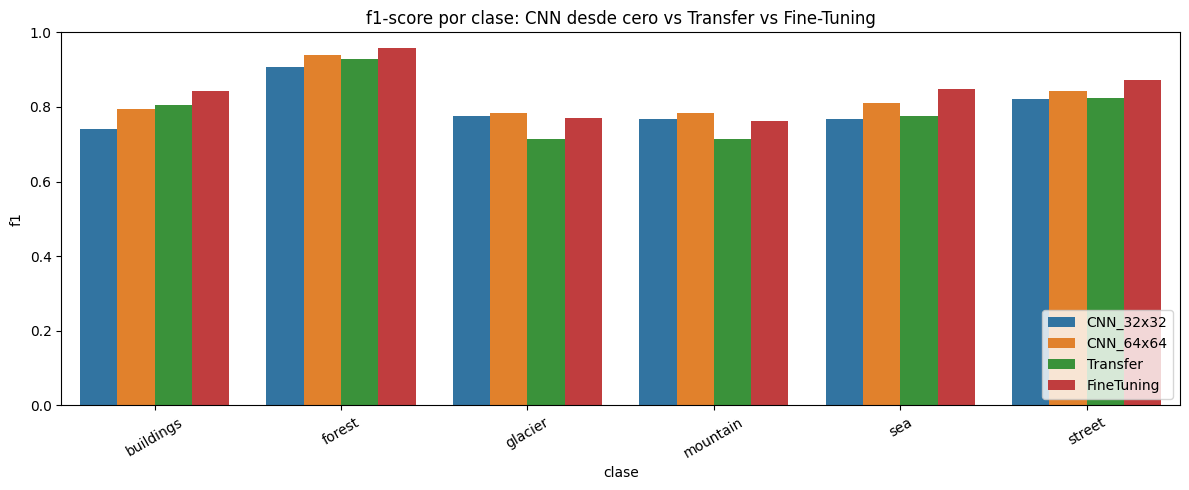

In [23]:
df_plot = df_f1.melt(id_vars="clase", var_name="modelo", value_name="f1")

plt.figure(figsize=(12, 5))
sns.barplot(data=df_plot, x="clase", y="f1", hue="modelo")
plt.title("f1-score por clase: CNN desde cero vs Transfer vs Fine-Tuning")
plt.ylim(0, 1)
plt.xticks(rotation=30)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Lectura de la comparativa**

Este es el punto 6 del enunciado, y da tres conclusiones distintas.

**1. El fine-tuning gana, el transfer learning solo no.**

| modelo | params entrenados | accuracy |
|---|---|---|
| RandomForest (baseline U1) | 0 | 60,4% |
| CNN desde cero, 32x32 (U1) | 619.334 | 79,6% |
| CNN desde cero, 64x64 (U1) | 2.192.198 | 82,4% |
| InceptionV3 transfer, 75x75 | **526.086** | 79,2% |
| InceptionV3 fine-tuning, 75x75 | 22.277.222 | **84,0%** |

El fine-tuning es el mejor de todos, pero el **transfer learning puro empata con
nuestra CNN pequeña de 32x32** y pierde contra la de 64x64. Un extractor entrenado con
ImageNet, usado sin tocar, no bate a una CNN modesta entrenada desde cero con nuestros
propios datos.

**2. Por qué el transfer no gana: estamos usando InceptionV3 fuera de su régimen.**
InceptionV3 se diseñó para imágenes de 299x299 y aquí la usamos a **75x75**, que es su
mínimo. A esa resolución sus features profundas (las que detectan objetos completos)
apenas tienen información espacial con la que trabajar: la salida de la base es de
`1x1x2048`, es decir un único punto. Las features siguen siendo genéricas de ImageNet,
que son fotos de objetos, no de paisajes. Solo cuando dejamos que se ajusten a nuestros
datos (fine-tuning) empiezan a rendir.

**3. El par `glacier`/`mountain` resiste a todo.** Mirando el f1 por clase, el
fine-tuning bate a la CNN de 64x64 en cuatro clases pero **pierde en dos**:

| clase | CNN 64x64 | Fine-tuning | diferencia |
|---|---|---|---|
| sea | 0.810 | 0.849 | **+0,039** |
| buildings | 0.794 | 0.843 | +0,049 |
| street | 0.842 | 0.871 | +0,029 |
| forest | 0.938 | 0.959 | +0,021 |
| mountain | 0.783 | 0.763 | **-0,020** |
| glacier | 0.784 | 0.770 | **-0,014** |

Es la misma conclusión a la que llegamos en la Unidad 1 subiendo la resolución: la
confusión entre glaciar y montaña **no se arregla con mejores features**, porque no es
un problema de percepción sino de que las etiquetas son ambiguas. Un glaciar
fotografiado de lejos *es* una montaña con hielo. Ni más píxeles ni un millón de
imágenes de preentrenamiento resuelven una etiqueta discutible.

***
## EXTRA: repetir el transfer learning con aumentado de imágenes

### Nota sobre `ImageDataGenerator` y Keras 3

El material del curso usa `ImageDataGenerator`, y con **Keras 3** el import que
aparece en los notebooks falla:

```python
from keras.preprocessing.image import ImageDataGenerator
# ImportError: cannot import name 'ImageDataGenerator'
```

La clase **no ha desaparecido**: sigue disponible como código legacy y se llega a
ella por el espacio de compatibilidad de TensorFlow, así que este import **sí
funciona**:

```python
from tensorflow.keras.preprocessing.image import ImageDataGenerator
```

Aquí usamos las **capas de aumentado** de Keras 3 (`RandomFlip`, `RandomRotation`,
`RandomZoom`), que es la API recomendada actualmente. La ventaja es que el aumentado
va dentro del modelo, así que se aplica solo en entrenamiento (se desactiva solo en
`evaluate` y `predict`) y viaja con el modelo si lo guardamos.

Qué transformaciones tienen sentido en paisajes:

* `RandomFlip("horizontal")`: una montaña reflejada sigue siendo una montaña. **Solo
  horizontal**: un volteo vertical daría paisajes del revés, con el cielo abajo, que
  no existen en el dataset.
* `RandomRotation(0.05)`: giros pequeños (un 5% de vuelta, unos 18 grados) para
  cubrir fotos ligeramente torcidas. Los mantenemos suaves porque en la Unidad 1
  vimos que rotar mucho a baja resolución destruye información.
* `RandomZoom(0.1)`: acerca o aleja un 10%.

Un detalle: como las imágenes ya están en [-1, 1], el relleno que dejan la rotación
y el zoom (valor 0) corresponde a un **gris medio**, no a negro. Eso es preferible,
porque mete menos artefacto que un borde negro.

In [24]:
model_aug = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # --- Aumentado: solo actua en entrenamiento ---
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),

    # --- La misma base congelada y la misma cabeza que en el punto 4 ---
    construye_modelo(congelar_base=True),
])

model_aug.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

entrenables = sum(int(tf.size(w)) for w in model_aug.trainable_weights)
print(f"Parametros entrenables: {entrenables:,} (los mismos que en el transfer: "
      f"las capas de aumentado no tienen pesos)")

Parametros entrenables: 526,086 (los mismos que en el transfer: las capas de aumentado no tienen pesos)


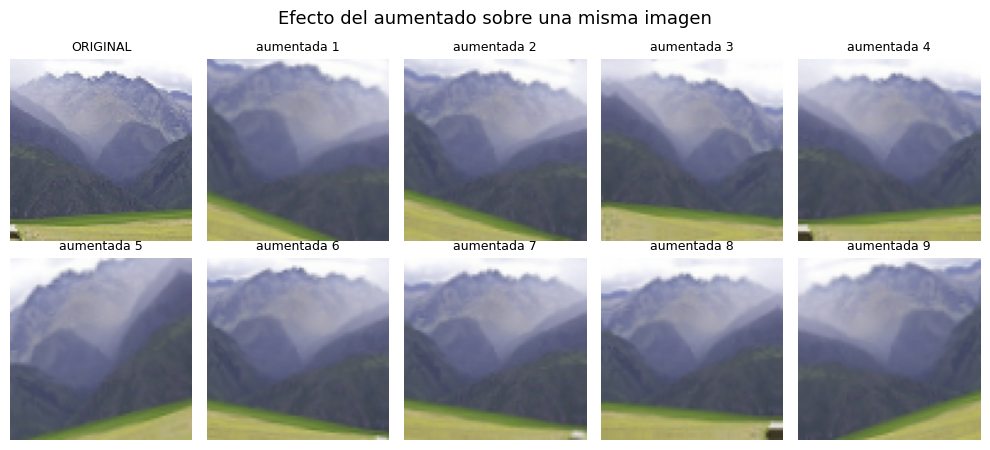

In [25]:
# Comprobamos que el aumentado hace lo que esperamos, sobre una imagen sin preprocesar
capas_aug = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
])

original = X_test_visual[0]
lote = np.expand_dims(original.astype("float32"), 0)
versiones = [original] + [
    np.array(capas_aug(lote, training=True))[0].astype("uint8") for _ in range(9)
]
etiquetas = ["ORIGINAL"] + [f"aumentada {i}" for i in range(1, 10)]

plot_imagenes(np.array(versiones), etiquetas, n_cols=5,
              titulo="Efecto del aumentado sobre una misma imagen")

In [26]:
early_aug = EarlyStopping(monitor="val_loss", patience=5,
                          restore_best_weights=True, verbose=1)

t0 = time.time()
hist_aug = model_aug.fit(X_train_pre, y_train_num,
                         batch_size=64,
                         epochs=30,
                         validation_split=0.2,
                         callbacks=[early_aug],
                         verbose=2)
print(f"\nEntrenamiento: {time.time() - t0:.0f}s")

Epoch 1/30


176/176 - 34s - 194ms/step - accuracy: 0.6671 - loss: 0.9223 - val_accuracy: 0.7606 - val_loss: 0.6739


Epoch 2/30


176/176 - 25s - 144ms/step - accuracy: 0.7445 - loss: 0.6899 - val_accuracy: 0.7738 - val_loss: 0.6192


Epoch 3/30


...

Epoch 15/30


176/176 - 25s - 143ms/step - accuracy: 0.8090 - loss: 0.5023 - val_accuracy: 0.7959 - val_loss: 0.5559


Epoch 15: early stopping


Restoring model weights from the end of the best epoch: 10.



Entrenamiento: 397s


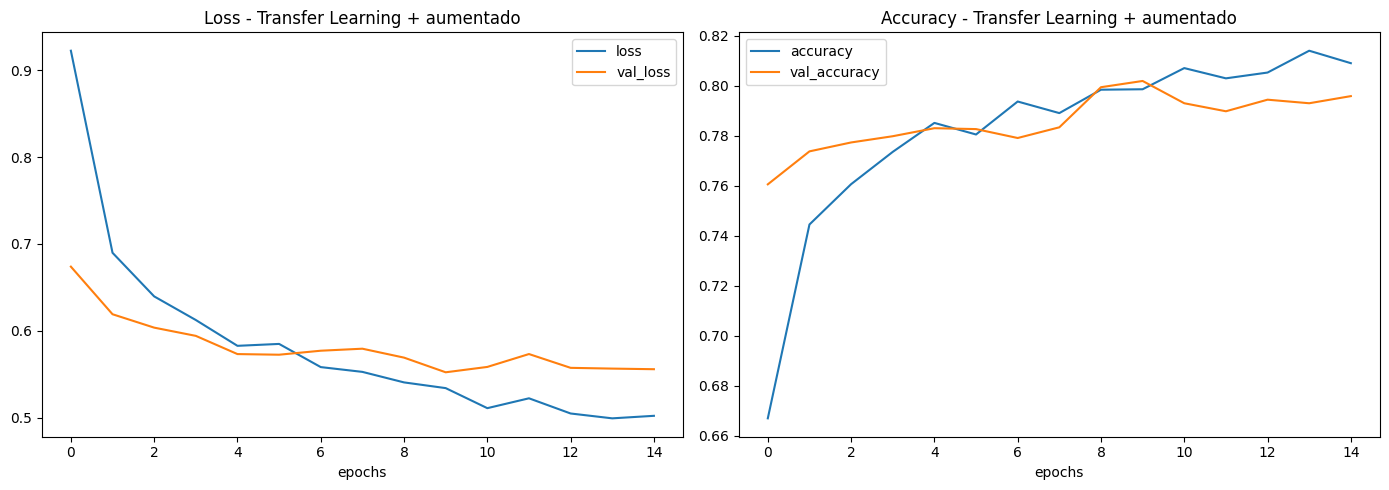

Epocas: 15 | mejor val_loss 0.5524 en epoca 10
En esa epoca: accuracy=0.7986 val_accuracy=0.8019 (diferencia -0.0033)


In [27]:
hist_aug_df = pinta_historial(hist_aug, "Transfer Learning + aumentado")

In [28]:
res_aug = evalua(model_aug, "TRANSFER + AUMENTADO", X_test_pre, y_test_num)

=== TRANSFER + AUMENTADO ===
Loss en test    : 0.5522
Accuracy en test: 0.7907  (79.1%)



              precision    recall  f1-score   support

   buildings       0.81      0.84      0.82       437
      forest       0.92      0.94      0.93       474
     glacier       0.77      0.66      0.71       553
    mountain       0.69      0.76      0.72       525
         sea       0.77      0.76      0.76       510
      street       0.82      0.82      0.82       501

    accuracy                           0.79      3000
   macro avg       0.79      0.80      0.79      3000
weighted avg       0.79      0.79      0.79      3000



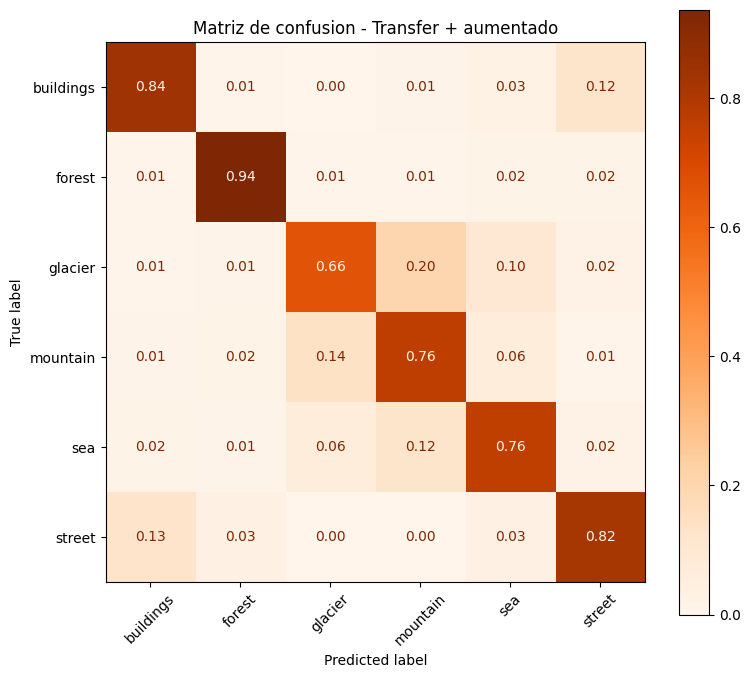

In [29]:
pinta_matriz(y_test_num, res_aug["pred"],
             "Matriz de confusion - Transfer + aumentado", cmap="Oranges")

**Lectura del aumentado**

Accuracy en test: **79,1%**, prácticamente idéntico al 79,2% del transfer sin
aumentado. No mejora.

Pero sí hace lo que promete como regularizador, y de forma espectacular:

| | accuracy train | accuracy validación | diferencia |
|---|---|---|---|
| transfer sin aumentado (mejor época) | 0.836 | 0.792 | +4,4 puntos |
| transfer con aumentado (mejor época) | 0.799 | 0.802 | **-0,3 puntos** |

La diferencia es **negativa**: la validación va ligeramente *mejor* que el
entrenamiento. Eso es un modelo sin una gota de overfitting. Y le costó 15 épocas
converger frente a las 9 de antes, justo porque cada época ve imágenes distintas.

Es el mismo resultado que en la práctica de la Unidad 1: **el aumentado elimina el
overfitting pero no compra accuracy**. Aquí la razón es distinta, y más interesante:
con la base congelada el modelo solo tiene 526.086 parámetros que ajustar, así que
**no estaba sobreajustando lo suficiente como para que regularizar sirviera de algo**.
El aumentado es la medicina correcta para el overfitting; si no hay overfitting, no
hay nada que curar.

Donde sí tendría sentido probarlo es combinado con el **fine-tuning**, que es el que
sobreajusta de verdad (96,6% en train frente a 85,1% en validación). Lo dejo apuntado
como siguiente paso.

In [30]:
# Tabla final con los tres modelos preentrenados
resumen = pd.DataFrame([
    {"modelo": "Transfer Learning", "epocas": len(hist_tl_df),
     "mejor_val_loss": round(hist_tl_df["val_loss"].min(), 4),
     "loss_test": round(res_tl["loss"], 4), "accuracy_test": round(res_tl["accuracy"], 4)},
    {"modelo": "Fine-Tuning", "epocas": len(hist_ft_df),
     "mejor_val_loss": round(hist_ft_df["val_loss"].min(), 4),
     "loss_test": round(res_ft["loss"], 4), "accuracy_test": round(res_ft["accuracy"], 4)},
    {"modelo": "Transfer + aumentado", "epocas": len(hist_aug_df),
     "mejor_val_loss": round(hist_aug_df["val_loss"].min(), 4),
     "loss_test": round(res_aug["loss"], 4), "accuracy_test": round(res_aug["accuracy"], 4)},
])
resumen

,modelo,epocas,mejor_val_loss,loss_test,accuracy_test
0,Transfer Learning,9,0.5825,0.5695,0.7917
1,Fine-Tuning,4,0.4555,0.4516,0.8400
2,Transfer + aumentado,15,0.5524,0.5522,0.7907


***
## Conclusiones

**Los resultados, de un vistazo**

| enfoque | accuracy test | params entrenados |
|---|---|---|
| CNN desde cero, 64x64 (Unidad 1) | 82,4% | 2.192.198 |
| InceptionV3 transfer learning | 79,2% | 526.086 |
| InceptionV3 transfer + aumentado | 79,1% | 526.086 |
| **InceptionV3 fine-tuning** | **84,0%** | 22.277.222 |

**Sobre transfer learning frente a fine-tuning**

1. El **fine-tuning es el ganador** (84,0%), y le saca casi 5 puntos al transfer
   learning puro. Confirma lo que dice la teoría de la unidad: *"finetuning se ajusta
   mejor a nuestro problema y da en general mejores resultados"*.
2. Pero el **transfer learning puro no basta** para este problema: con 79,2% empata
   con nuestra CNN de 32x32 y pierde contra la de 64x64. La razón es que estamos
   usando InceptionV3 a 75x75, su mínimo, cuando fue diseñada para 299x299; y que
   ImageNet son fotos de objetos, no de paisajes. Las features genéricas no encajan
   bien con nuestro dominio hasta que las dejamos moverse.
3. El coste computacional confirma la tabla de la teoría: **25 s por época en transfer
   frente a ~165 s en fine-tuning**, porque pasamos de entrenar el 2,4% de los
   parámetros al 99,8%.

**Sobre cómo hacer el fine-tuning bien**

4. Las tres precauciones del punto 5 funcionaron y se pueden comprobar en la salida:
   la `val_loss` de la primera época del fine-tuning fue **0.4555**, mejor que el
   0.5825 donde había terminado el transfer. Sin ellas, lo típico es ver la `val_loss`
   dispararse a miles en la primera época y no recuperarse nunca.
5. El fine-tuning **sobreajusta muy rápido**: la mejor época fue la primera y en la
   cuarta el modelo ya iba por 96,6% en train contra 85,1% en validación.
   `restore_best_weights=True` es imprescindible aquí, no un adorno.

**Sobre el aumentado (EXTRA)**

6. El aumentado **elimina el overfitting por completo** (la diferencia train-validación
   pasa de +4,4 a -0,3 puntos) pero **no mejora la accuracy** (79,1% frente a 79,2%).
   Con la base congelada solo hay medio millón de parámetros que ajustar, así que no
   había overfitting suficiente para que regularizar aportara nada.
7. Lo lógico sería aplicarlo al **fine-tuning**, que es el que sí sobreajusta.

**Lo que resiste a todo**

8. La confusión `glacier` <-> `mountain` no la arregla nada de lo que hemos probado.
   El fine-tuning bate a la CNN desde cero en cuatro clases, pero **pierde en esas dos
   precisamente** (-0,020 y -0,014 de f1). En la Unidad 1 llegamos a la misma
   conclusión subiendo la resolución. No es un problema de features ni de píxeles: es
   que la etiqueta es ambigua, porque un glaciar de lejos es una montaña con hielo.

**Siguientes pasos**

9. Por orden de rentabilidad esperada:
   * **Subir la resolución a 150x150 o 224x224**, que es donde estos modelos rinden de
     verdad. Es lo que más margen tiene, y el cuello de botella es solo tiempo de CPU.
   * **Fine-tuning + aumentado**, combinando el que mejora la accuracy con el que
     controla el overfitting.
   * **Descongelar solo los bloques superiores** en lugar de toda la base: mucho más
     barato y a menudo igual de bueno.